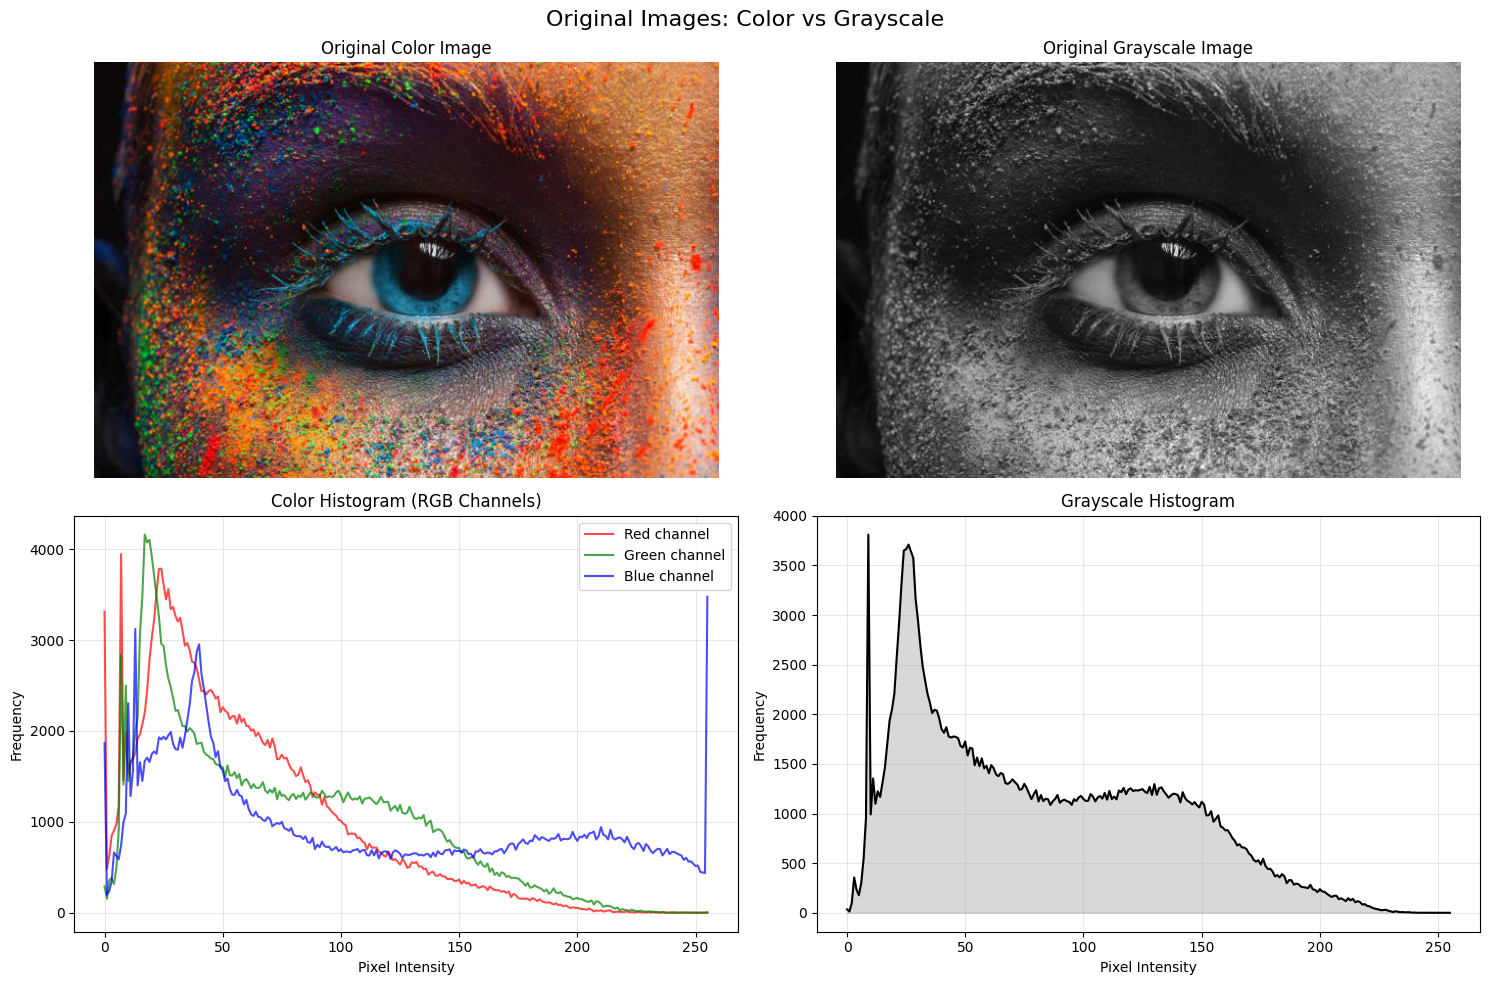

In [16]:

img_color = cv.imread('eye.jpg')  
img_gray = cv.imread('eye.jpg', cv.IMREAD_GRAYSCALE)  


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Original Images: Color vs Grayscale', fontsize=16)


axes[0, 0].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Color Image')
axes[0, 0].axis('off')


axes[0, 1].imshow(img_gray, cmap='gray')
axes[0, 1].set_title('Original Grayscale Image')
axes[0, 1].axis('off')


colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    hist = cv.calcHist([img_color], [i], None, [256], [0, 256])
    axes[1, 0].plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()} channel')
axes[1, 0].set_title('Color Histogram (RGB Channels)')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


hist_gray = cv.calcHist([img_gray], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_gray, color='black')
axes[1, 1].fill_between(range(256), hist_gray.flatten(), alpha=0.3, color='gray')
axes[1, 1].set_title('Grayscale Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

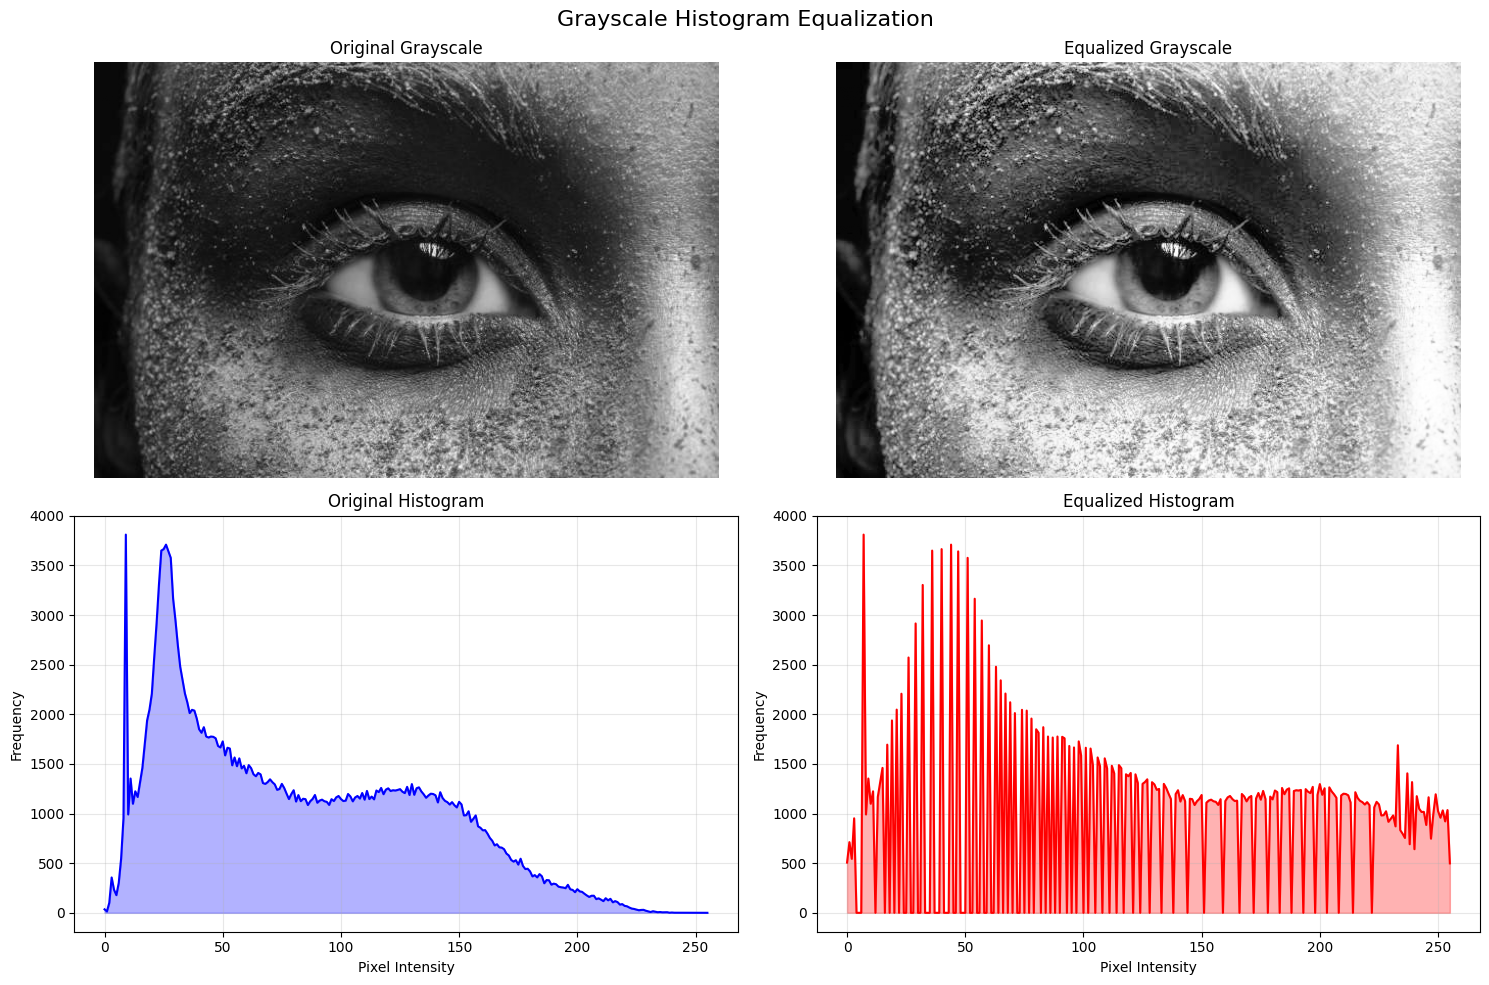

Grayscale comparison saved as 'gray_comparison.png'


In [14]:
# Grayscale Histogram Equalization
img_gray_eq = cv.equalizeHist(img_gray)

# Create comparison plot for grayscale equalization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Grayscale Histogram Equalization', fontsize=16)

# Original grayscale image
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

# Equalized grayscale image
axes[0, 1].imshow(img_gray_eq, cmap='gray')
axes[0, 1].set_title('Equalized Grayscale')
axes[0, 1].axis('off')

# Original histogram
hist_orig = cv.calcHist([img_gray], [0], None, [256], [0, 256])
axes[1, 0].plot(hist_orig, color='blue')
axes[1, 0].fill_between(range(256), hist_orig.flatten(), alpha=0.3, color='blue')
axes[1, 0].set_title('Original Histogram')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Equalized histogram
hist_eq = cv.calcHist([img_gray_eq], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_eq, color='red')
axes[1, 1].fill_between(range(256), hist_eq.flatten(), alpha=0.3, color='red')
axes[1, 1].set_title('Equalized Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the comparison
comparison_gray = np.hstack((img_gray, img_gray_eq))
cv.imwrite('gray_comparison.png', comparison_gray)
print("Grayscale comparison saved as 'gray_comparison.png'")

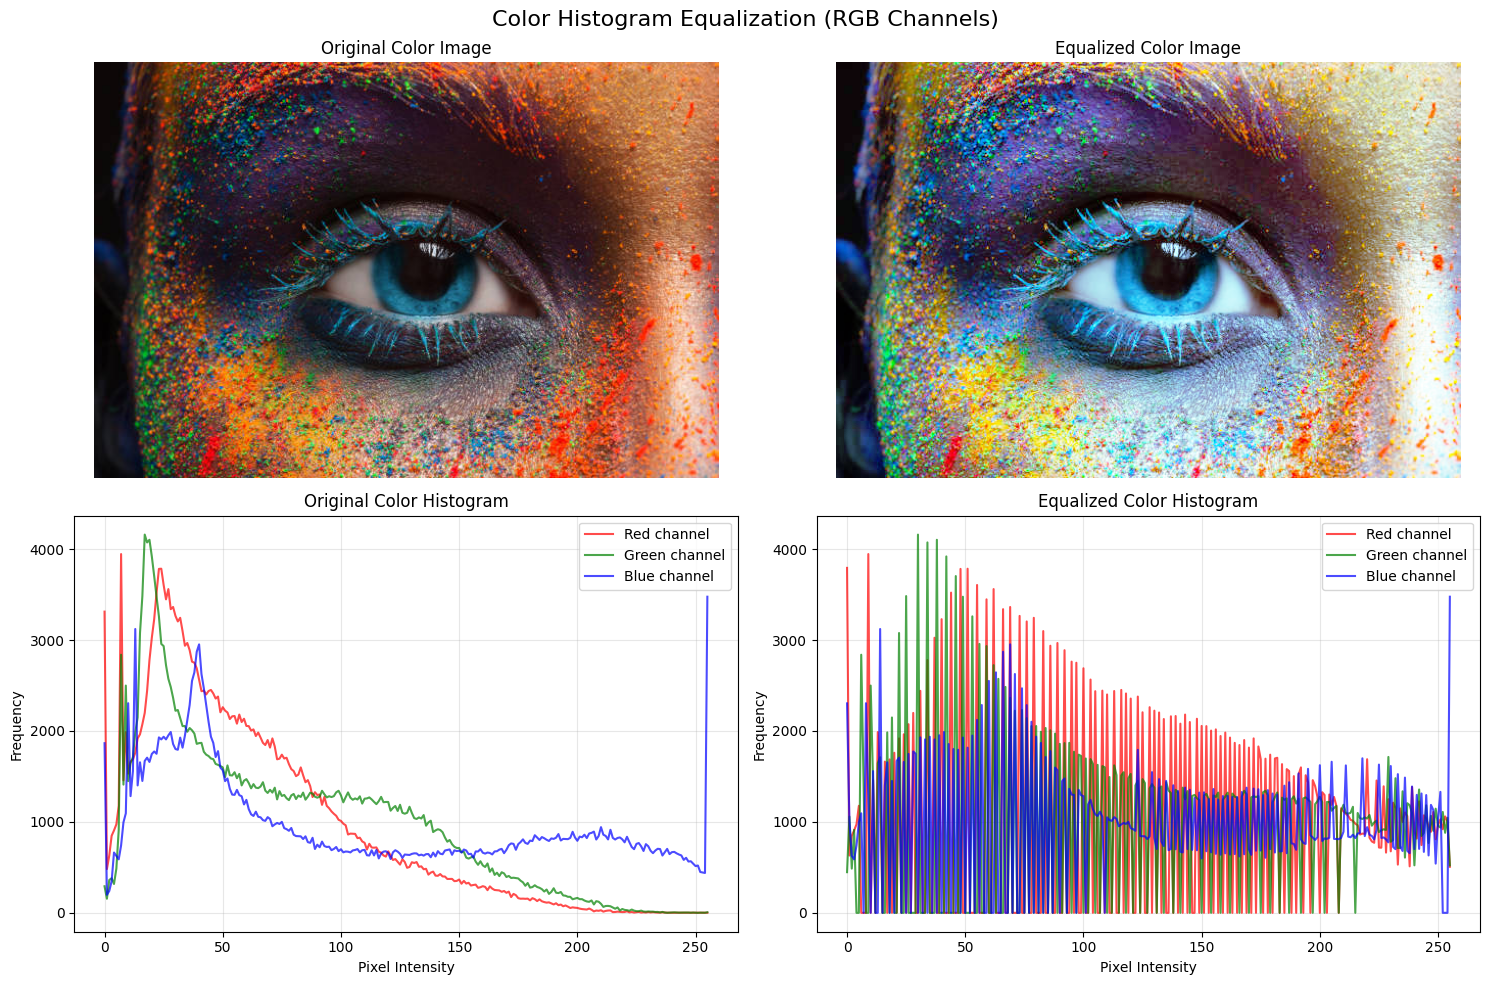

Color comparison saved as 'color_comparison.png'


In [15]:
# Color Histogram Equalization (RGB channels)
def equalize_color_image(img):
    """Apply histogram equalization to each RGB channel separately"""
    # Split the image into RGB channels
    b, g, r = cv.split(img)
    
    # Apply histogram equalization to each channel
    b_eq = cv.equalizeHist(b)
    g_eq = cv.equalizeHist(g)
    r_eq = cv.equalizeHist(r)
    
    # Merge the equalized channels
    img_eq = cv.merge([b_eq, g_eq, r_eq])
    return img_eq

# Apply color histogram equalization
img_color_eq = equalize_color_image(img_color)

# Create comparison plot for color equalization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Color Histogram Equalization (RGB Channels)', fontsize=16)

# Original color image
axes[0, 0].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Color Image')
axes[0, 0].axis('off')

# Equalized color image
axes[0, 1].imshow(cv.cvtColor(img_color_eq, cv.COLOR_BGR2RGB))
axes[0, 1].set_title('Equalized Color Image')
axes[0, 1].axis('off')

# Original color histogram
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    hist = cv.calcHist([img_color], [i], None, [256], [0, 256])
    axes[1, 0].plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()} channel')
axes[1, 0].set_title('Original Color Histogram')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Equalized color histogram
for i, color in enumerate(colors):
    hist = cv.calcHist([img_color_eq], [i], None, [256], [0, 256])
    axes[1, 1].plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()} channel')
axes[1, 1].set_title('Equalized Color Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the color comparison
color_comparison = np.hstack((img_color, img_color_eq))
cv.imwrite('color_comparison.png', color_comparison)
print("Color comparison saved as 'color_comparison.png'")

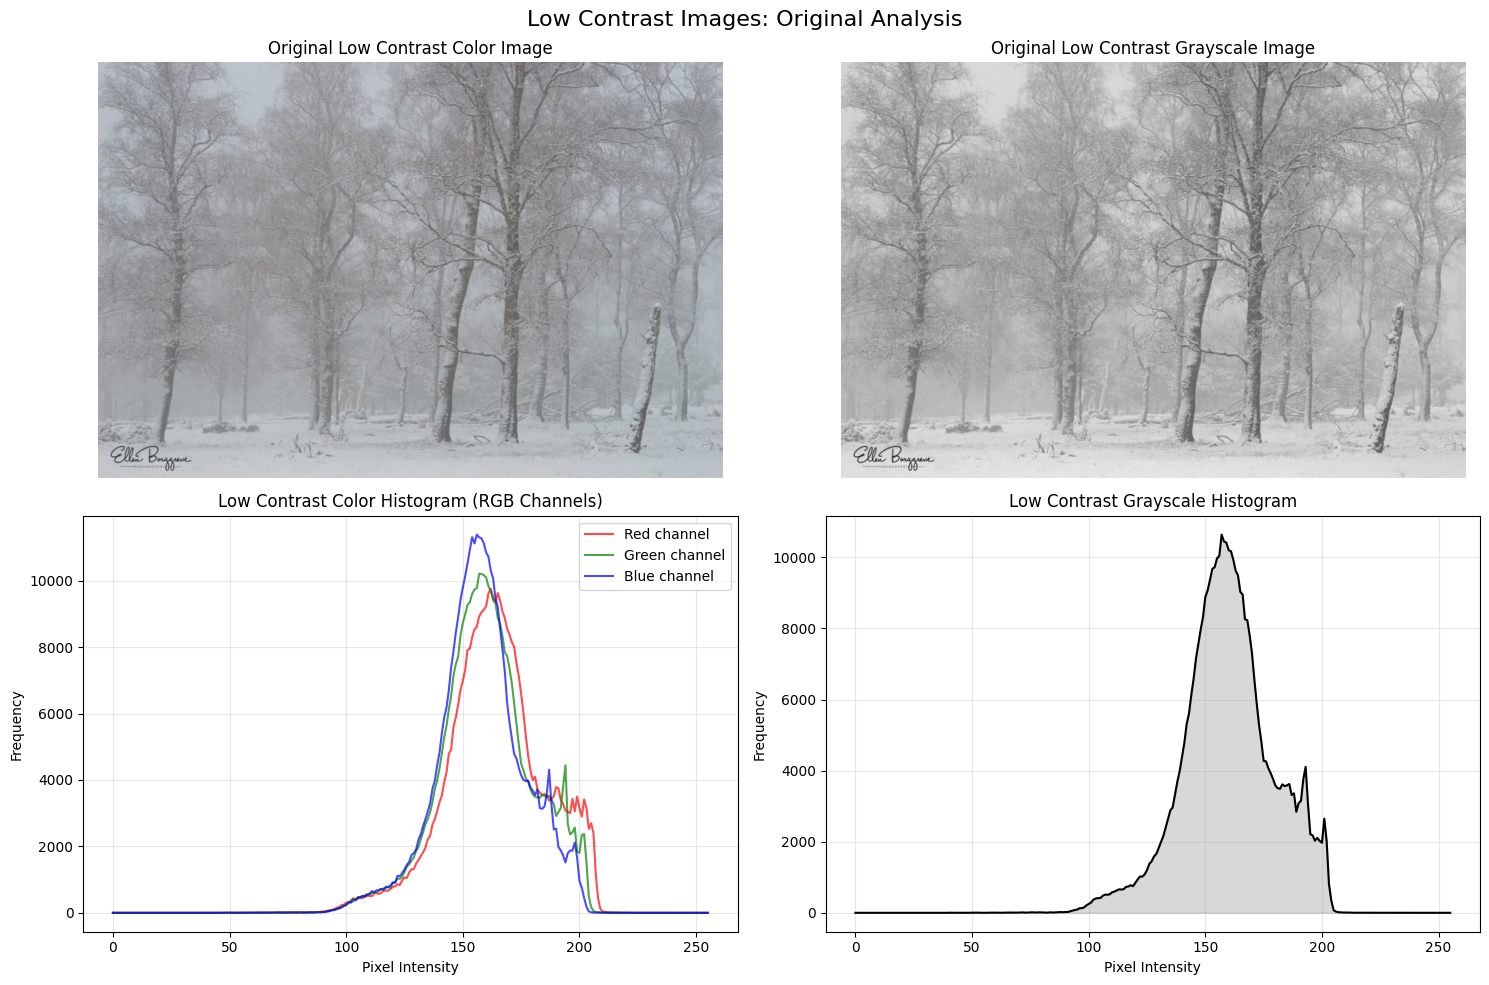

Low contrast color image shape: (533, 800, 3)
Low contrast grayscale image shape: (533, 800)


In [17]:
# Load the low contrast image
img_low_color = cv.imread('low.jpg')  
img_low_gray = cv.imread('low.jpg', cv.IMREAD_GRAYSCALE)  

# Display original low contrast images with histograms
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Low Contrast Images: Original Analysis', fontsize=16)

# Original low contrast color image
axes[0, 0].imshow(cv.cvtColor(img_low_color, cv.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Low Contrast Color Image')
axes[0, 0].axis('off')

# Original low contrast grayscale image
axes[0, 1].imshow(img_low_gray, cmap='gray')
axes[0, 1].set_title('Original Low Contrast Grayscale Image')
axes[0, 1].axis('off')

# Color histogram for low contrast image
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    hist = cv.calcHist([img_low_color], [i], None, [256], [0, 256])
    axes[1, 0].plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()} channel')
axes[1, 0].set_title('Low Contrast Color Histogram (RGB Channels)')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Grayscale histogram for low contrast image
hist_low_gray = cv.calcHist([img_low_gray], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_low_gray, color='black')
axes[1, 1].fill_between(range(256), hist_low_gray.flatten(), alpha=0.3, color='gray')
axes[1, 1].set_title('Low Contrast Grayscale Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Low contrast color image shape: {img_low_color.shape}")
print(f"Low contrast grayscale image shape: {img_low_gray.shape}")

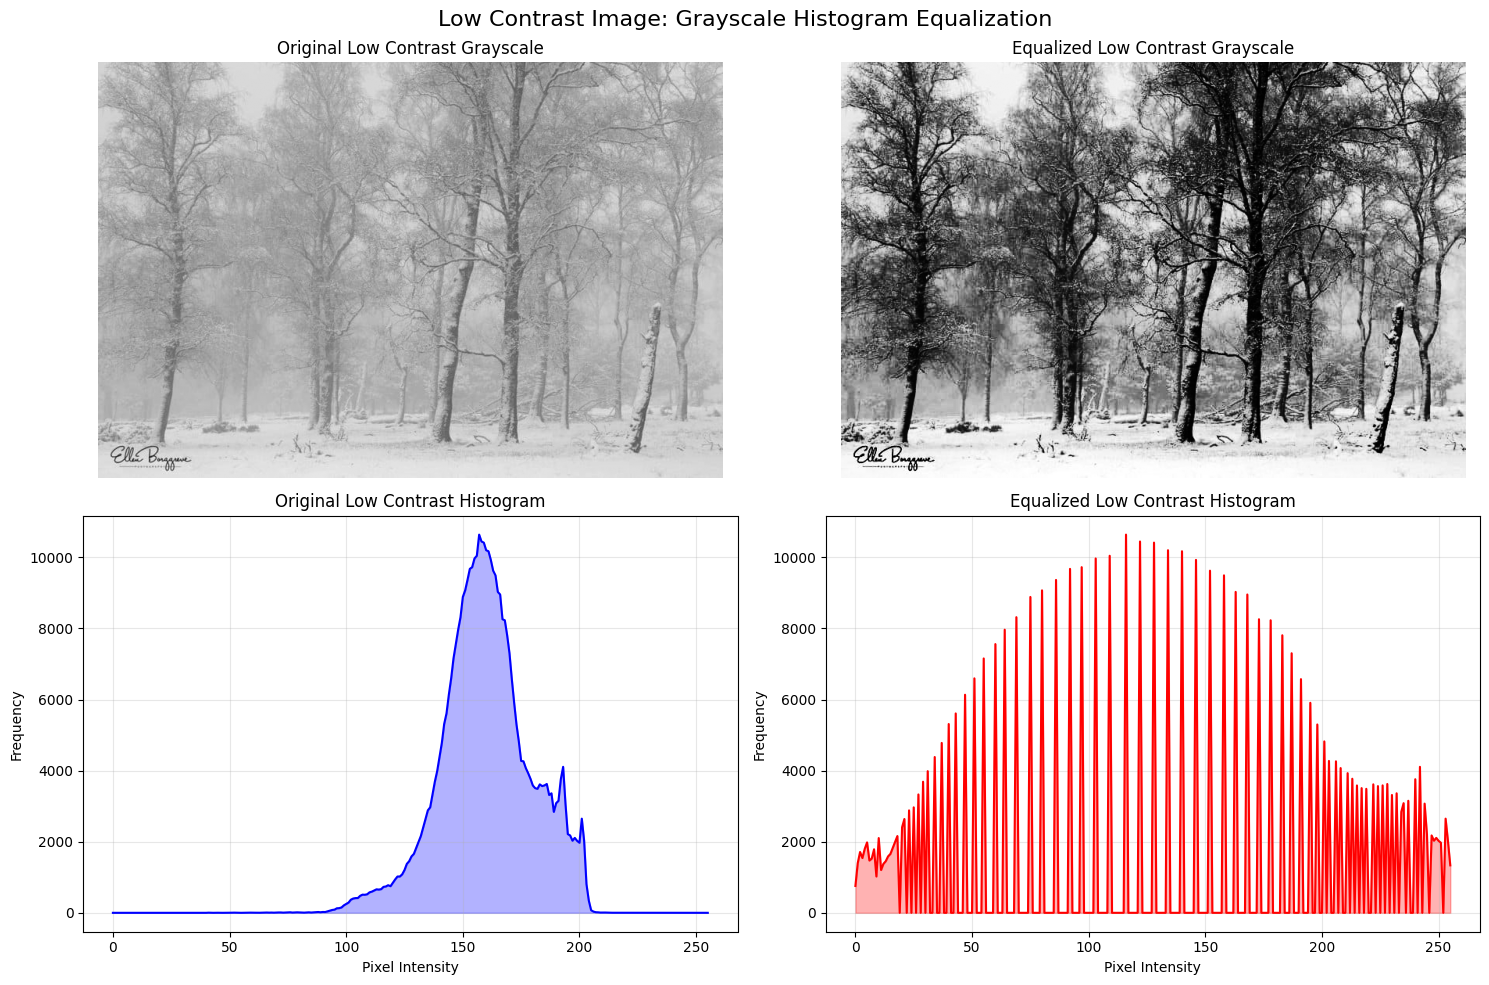

Low contrast grayscale comparison saved as 'low_contrast_gray_comparison.png'


In [18]:
# Grayscale Histogram Equalization for Low Contrast Image
img_low_gray_eq = cv.equalizeHist(img_low_gray)

# Create comparison plot for low contrast grayscale equalization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Low Contrast Image: Grayscale Histogram Equalization', fontsize=16)

# Original low contrast grayscale image
axes[0, 0].imshow(img_low_gray, cmap='gray')
axes[0, 0].set_title('Original Low Contrast Grayscale')
axes[0, 0].axis('off')

# Equalized low contrast grayscale image
axes[0, 1].imshow(img_low_gray_eq, cmap='gray')
axes[0, 1].set_title('Equalized Low Contrast Grayscale')
axes[0, 1].axis('off')

# Original histogram
hist_low_orig = cv.calcHist([img_low_gray], [0], None, [256], [0, 256])
axes[1, 0].plot(hist_low_orig, color='blue')
axes[1, 0].fill_between(range(256), hist_low_orig.flatten(), alpha=0.3, color='blue')
axes[1, 0].set_title('Original Low Contrast Histogram')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Equalized histogram
hist_low_eq = cv.calcHist([img_low_gray_eq], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_low_eq, color='red')
axes[1, 1].fill_between(range(256), hist_low_eq.flatten(), alpha=0.3, color='red')
axes[1, 1].set_title('Equalized Low Contrast Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the low contrast grayscale comparison
low_contrast_gray_comparison = np.hstack((img_low_gray, img_low_gray_eq))
cv.imwrite('low_contrast_gray_comparison.png', low_contrast_gray_comparison)
print("Low contrast grayscale comparison saved as 'low_contrast_gray_comparison.png'")